In [9]:
# Load environment variables and set up auto-reload
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Multi-Agent Research System

This notebook combines all the previous components into a single system.

Here is our overall research flow:

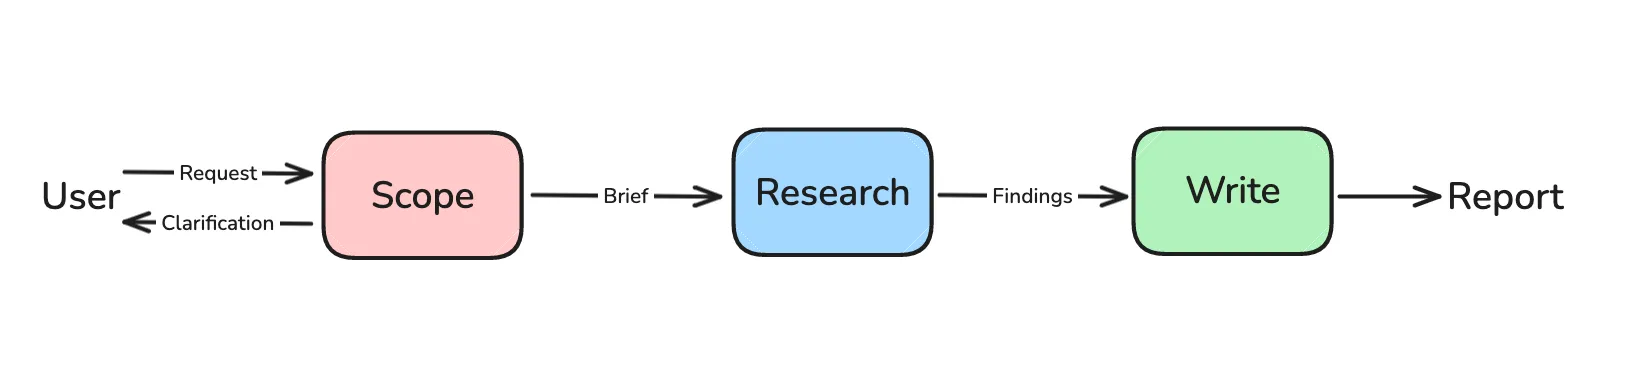

We've built research scoping and multi-agent research in previous notebooks.

Now, we'll add the final report generation step.

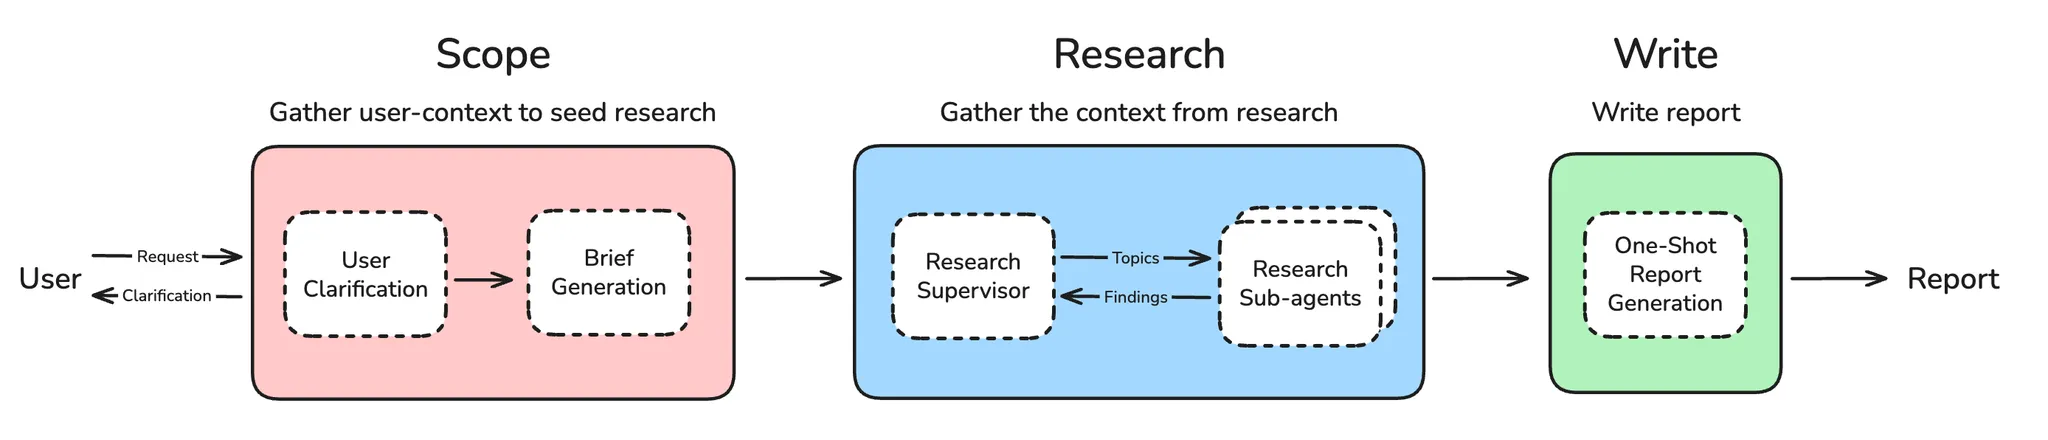

### Agent 

We simply can re-use the components we've already built.

In [10]:
%%writefile ../src/deep_research_from_scratch/research_agent_full.py

"""
Full Multi-Agent Research System

This module integrates all components of the research system:
- User clarification and scoping
- Research brief generation  
- Multi-agent research coordination
- Final report generation

The system orchestrates the complete research workflow from initial user
input through final report delivery.
"""

from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END

from deep_research_from_scratch.utils import get_today_str
from deep_research_from_scratch.prompts import final_report_generation_prompt
from deep_research_from_scratch.state_scope import AgentState, AgentInputState
from deep_research_from_scratch.research_agent_scope import clarify_with_user, write_research_brief
from deep_research_from_scratch.multi_agent_supervisor import supervisor_agent

# ===== Config =====

from langchain.chat_models import init_chat_model
writer_model = init_chat_model(model="openai:gpt-4.1", max_tokens=32000) # model="anthropic:claude-sonnet-4-6", max_tokens=64000

# ===== FINAL REPORT GENERATION =====

from deep_research_from_scratch.state_scope import AgentState

async def final_report_generation(state: AgentState):
    """
    Final report generation node.
    
    Synthesizes all research findings into a comprehensive final report
    """
    
    notes = state.get("notes", [])
    
    findings = "\n".join(notes)

    final_report_prompt = final_report_generation_prompt.format(
        research_brief=state.get("research_brief", ""),
        findings=findings,
        date=get_today_str()
    )
    
    final_report = await writer_model.ainvoke([HumanMessage(content=final_report_prompt)])
    
    return {
        "final_report": final_report.content, 
        "messages": ["Here is the final report: " + final_report.content],
    }

# ===== GRAPH CONSTRUCTION =====
# Build the overall workflow
deep_researcher_builder = StateGraph(AgentState, input_schema=AgentInputState)

# Add workflow nodes
deep_researcher_builder.add_node("clarify_with_user", clarify_with_user)
deep_researcher_builder.add_node("write_research_brief", write_research_brief)
deep_researcher_builder.add_node("supervisor_subgraph", supervisor_agent)
deep_researcher_builder.add_node("final_report_generation", final_report_generation)

# Add workflow edges
deep_researcher_builder.add_edge(START, "clarify_with_user")
deep_researcher_builder.add_edge("write_research_brief", "supervisor_subgraph")
deep_researcher_builder.add_edge("supervisor_subgraph", "final_report_generation")
deep_researcher_builder.add_edge("final_report_generation", END)

# Compile the full workflow
agent = deep_researcher_builder.compile()

Overwriting ../src/deep_research_from_scratch/research_agent_full.py


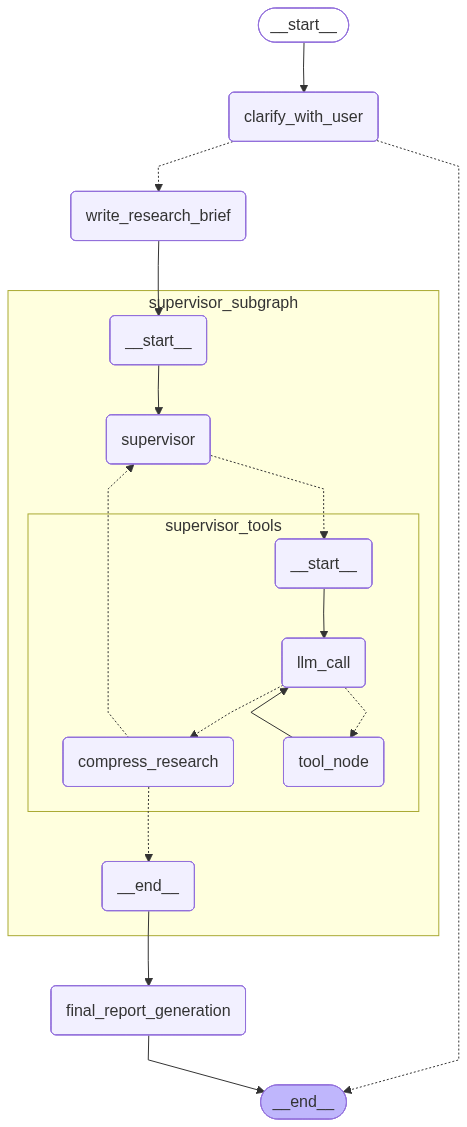

In [11]:
# Run the workflow
from utils import format_messages
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from deep_research_from_scratch.research_agent_full import deep_researcher_builder

checkpointer = InMemorySaver()
full_agent = deep_researcher_builder.compile(checkpointer=checkpointer)
display(Image(full_agent.get_graph(xray=True).draw_mermaid_png()))

LangGraph has a default recursion limit of 25 steps to prevent infinite loops. For complex research workflows that require iterative rounds of research, this limit needs to be increased. As explained in [LangGraph's troubleshooting guide](https://langchain-ai.github.io/langgraph/troubleshooting/errors/GRAPH_RECURSION_LIMIT/), the recursion limit counts every node execution in the graph. In our multi-agent research system:

- **Single Research Agent**: May take 8-12 steps for tool calls and compression
- **Multi-Agent Supervisor**: Each sub-agent spawned adds additional steps
- **Iterative Research**: Supervisor may conduct multiple rounds of research to fill gaps
- **Full Workflow**: Includes scoping, research brief generation, supervision, and report generation

We set the recursion limit to **50** to accommodate:
- Complex research topics requiring multiple research rounds
- Parallel sub-agent execution
- Deep research with many tool calls
- Complete workflow execution from scoping to final report

This allows the supervisor to conduct iterative rounds of research when initial findings have gaps, ensuring comprehensive coverage of complex research topics.

In [12]:
from langchain_core.messages import HumanMessage
thread = {"configurable": {"thread_id": "1", "recursion_limit": 50}}
result = await full_agent.ainvoke({"messages": [HumanMessage(content="Compare Gemini to OpenAI Deep Research agents.")]}, config=thread)
format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Compare Gemini to OpenAI Deep Research agents.                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Could you clarify what you mean by "OpenAI Deep Research agents"? Are you referring to OpenAI's GPT-4/5 models, │
│ their autonomous research agents (like AutoGPT or similar), or a specific product or project? Also, are you     │
│ interested in a technical comparison, use cases, or performance benchmarks?                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [ ]:
result = await full_agent.ainvoke({"messages": [HumanMessage(content="Yes the specific Deep Research products.")]}, config=thread)

In [7]:
format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Compare Gemini to OpenAI Deep Research agents.                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Could you clarify what you mean by 'Gemini'? Are you referring to Google's Gemini AI model, or another system?  │
│ Also, by 'OpenAI Deep Research agents', do you mean OpenAI's advanced research models (like GPT-4/5) or a       │
│ specific research agent product? Please specify so I can provide an accurate comparison.                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Yes the specific Deep Research products.                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Thank you for clarifying. I understand that you would like a comparison between Google's Gemini AI model and    │
│ OpenAI's specific Deep Research products. I will now begin the research and provide a detailed comparison based │
│ on these criteria.                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Here is the final report: # Comprehensive Comparison: Google Gemini AI Model vs. OpenAI Deep Research Products  │
│ (2026)                                                                                                          │
│                                                                                                                 │
│ ## Introduction                                                                                                 │
│                                                                                                                 │
│ This report provides an in-depth comparison of Google’s Gemini AI model—focusing on its Deep Research           │
│ capability—and OpenAI’s Deep Research products. The analysis covers key aspects including model architecture,   │
│ features, reasoning and benchmarking performance, intended use cases, integration options, real-world           │
│ applications, pricing, and practical limitations. Citations from official documentation, benchmark reports,     │
│ independent user reviews, and technical publications are included to ensure accuracy and transparency.          │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ## Overview: Google Gemini AI & Deep Research                                                                   │
│                                                                                                                 │
│ ### Model Architecture and Evolution                                                                            │
│                                                                                                                 │
│ - **Gemini Model Family**: Developed by Google DeepMind, the Gemini series has rapidly evolved through Gemini   │
│ 1.5, 2.0, 2.5, and into the Gemini 3 family. Models employ a sparse Mixture-of-Experts (MoE) transformer        │
│ architecture, delivering native multimodality: text, images, audio, video, Python code, and increasingly, live  │
│ real-world action via tool use and robotics[1][2][3].                                                           │
│ - **Context Window**: Gemini supports exceptionally long input windows—up to 1 million tokens (with some        │
│ variants soon supporting 2 million)—enabling it to process entire codebases, long research documents, and hours │
│ of video/audio in a single session[4][5].                                                                       │
│ - **Deep Reasoning**: The models feature “Thinking” modes (configurable reasoning budgets), chain-of-thought    │
│ reasoning, and integrated tool use (search, code execution, external agents)[3][6].                             │
│                                                                                                                 │
│ ### Gemini Deep Research: Capabilities                                                                          │
│                                                                                                                 │
│ - **Autonomous Research Agent**: Launched in December 2024, Deep Research leverages Gemini’s frontier models to │
│ autonomously plan, execute, and synthesize multi-step investigations across the web and user-provided files     │
│ (images, PDFs)[7][8].                                                                                           │
│ - **Research Workflow**: The agent drafts structured research plans, collects information from hundreds of      │
│ sources (web, Gmail, Drive, NotebookLM, uploads), revie

In [8]:
from rich.markdown import Markdown
Markdown(result["final_report"])

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃            Comprehensive Comparison: Google Gemini AI Model vs. OpenAI Deep Research Products (2026)            ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛


                                                   Introduction                                                    

This report provides an in-depth comparison of Google’s Gemini AI model—focusing on its Deep Research              
capability—and OpenAI’s Deep Research products. The analysis covers key aspects including model architecture,      
features, reasoning and benchmarking performance, intended use cases, integration options, real-world applications,
pricing, and practical limitations. Citations from official documentation, benchmark reports, independent user     
reviews, and technical publications are included to ensure accuracy and transparency.                              

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────

                                    Overview: Google Gemini AI & Deep Research                                     

                                         Model Architecture and Evolution                                          

 • Gemini Model Family: Developed by Google DeepMind, the Gemini series has rapidly evolved through Gemini 1.5,    
   2.0, 2.5, and into the Gemini 3 family. Models employ a sparse Mixture-of-Experts (MoE) transformer             
   architecture, delivering native multimodality: text, images, audio, video, Python code, and increasingly, live  
   real-world action via tool use and robotics[1][2][3].                                                           
 • Context Window: Gemini supports exceptionally long input windows—up to 1 million tokens (with some variants soon
   supporting 2 million)—enabling it to process entire codebases, long research documents, and hours of video/audio
   in a single session[4][5].                                                                                      
 • Deep Reasoning: The models feature “Thinking” modes (configurable reasoning budgets), chain-of-thought          
   reasoning, and integrated tool use (search, code execution, external agents)[3][6].                             

                                        Gemini Deep Research: Capabilities                                         

 • Autonomous Research Agent: Launched in December 2024, Deep Research leverages Gemini’s frontier models to       
   autonomously plan, execute, and synthesize multi-step investigations across the web and user-provided files     
   (images, PDFs)[7][8].                                                                                           
 • Research Workflow: The agent drafts structured research plans, collects information from hundreds of sources    
   (web, Gmail, Drive, NotebookLM, uploads), reviews and synthesizes them into detailed, well-cited reports with up
   to 50 sources, and presents findings with audio/podcast-style summaries[9][10].                                 
 • Multimodal Input/Output: Accepts text, images, video, and document uploads, and can generate charts, tables, and
   visualizations within collaborative tools like Google Canvas and Docs[11].                                      
 • Integration: Natively integrates with Google Workspace (Gmail, Docs, Drive), Vertex AI, Google AI Studio, and is
   available via Gemini API (including deployment options for enterprise and developer workflows)[12].             
 • Processing: Reports typically require 5–15 minutes; more complex research can take up to 60 minutes. Two agent  
   versions are available: standard (for efficiency) and max (for comprehensiveness)[13].                          
 • Security/Ethics: Implements robust safety fi

We can see the trace [here](https://smith.langchain.com/public/86ebdc25-4595-4040-be1e-a8e30052786b/r).

### LangGraph Studio

Just as we did before, we can also use LangGraph Studio to visualize the agent. 

The files we wrote with `%%writefile` to `src/deep_research_from_scratch/` during the all the notebooks create the files for our application:

```
deep_research_from_scratch/
├── src/deep_research_from_scratch/
│   ├── state.py          # State definitions
│   ├── scope_research.py # Scoping workflow
│   ├── prompts.py        # Prompt templates
│   └── ...
├── notebooks/            # Development notebooks
├── pyproject.toml        # Dependencies
└── langgraph.json        # LangGraph configuration
```

This agent has been added to the `langgraph.json` file, so you can select `research_agent_full` in the dropdown menu:

```
"research_agent_full": "./src/deep_research_from_scratch/research_agent_full.py:agent"
```

Run the following command to start the studio

```bash
uvx --refresh --from "langgraph-cli[inmem]" --with-editable . --python 3.11 langgraph dev --allow-blocking
```